<h1><font color="blue">데이터 그룹화</font></h1>

<h2><font color="red">그룹 바이 메카니즘(mechanism)</font></h2>

<h4><font color="green">출장 내역 데이터</font></h4>

<h6><font color="BlueViolet">데이터 읽기</font></h6>

In [59]:
import pandas as pd

In [60]:
filename = './../data/payment07.csv'
payment = pd.read_csv(filename, encoding='CP949')
payment['성별'].unique()

array(['남자', '여자'], dtype=object)

In [61]:
payment

,사원명,출장지역,출장기간,부서,성별,교통비,식비
0,윤장혁,서울,7,영업부,남자,4000,2000
1,서문덕,서울,6,영업부,남자,3000,3000
2,이성진,부산,5,영업부,남자,3000,3000
3,강찬혁,부산,3,영업부,남자,1000,2000
4,신유석,서울,5,전산부,여자,2000,2000
5,유지혜,서울,5,전산부,여자,4000,1000
6,이유리,부산,8,전산부,여자,4000,1000
7,선진희,부산,6,전산부,여자,1000,4000


<h6><font color="BlueViolet">'성별'에 따른 '교통비' 집계</font></h6>

In [62]:
mygrouping = payment.groupby('성별')['교통비']
mygrouping.sum().to_frame()

,교통비
성별,
남자,11000
여자,11000


In [63]:
mygrouping.count().to_frame()

,교통비
성별,
남자,4
여자,4


<h6><font color="BlueViolet">agg() 메소드를 사용한 집계</font></h6>

In [64]:
# 데이터프레임 또는 시리즈에서 여러 가지 집계 함수를 한 번에 적용하고자 할 때 유용하게 사용합니다.
result = payment.groupby('성별')['출장기간'].agg('mean')
result.to_frame()

,출장기간
성별,
남자,5.25
여자,6.00


In [65]:
agg_dict = {'출장기간':'mean'}
result = payment.groupby('성별').agg(agg_dict)
result

,출장기간
성별,
남자,5.25
여자,6.00


<h6><font color="BlueViolet">2개 이상의 컬럼에 대한 집계</font></h6>

In [66]:
print(payment['출장지역'].unique())

['서울' '부산']


In [67]:
# '출장지역'별 '성별'의 '교통비'의 총합('sum')을 구해 보세요.
result = payment.groupby(['출장지역', '성별'])['교통비'].agg('sum')
result.to_frame()

교통비
출장지역 성별      
부산   남자  4000
     여자  5000
서울   남자  7000
     여자  6000

In [68]:
# '출장지역'별 '성별'의 '교통비'와 '출장기간'의 총합과 평균을 각각 구해 보세요.
result = payment.groupby(['출장지역', '성별'])[['교통비', '출장기간']].agg(['sum', 'mean'])
result

교통비         출장기간     
          sum    mean  sum mean
출장지역 성별                        
부산   남자  4000  2000.0    8  4.0
     여자  5000  2500.0   14  7.0
서울   남자  7000  3500.0   13  6.5
     여자  6000  3000.0   10  5.0

In [69]:
mydict = {'교통비':['sum', 'mean', 'max'], '출장기간':['mean', 'min']}
groupdata = payment.groupby(['출장지역', '성별']).agg(mydict).astype(int)
groupdata

교통비             출장기간    
          sum  mean   max mean min
출장지역 성별                           
부산   남자  4000  2000  3000    4   3
     여자  5000  2500  4000    7   6
서울   남자  7000  3500  4000    6   6
     여자  6000  3000  4000    5   5

<h2><font color="red">중첩 색인 제거하기</font></h2>

<h4><font color="green">중첩된 색인 만들기</font></h4>

<h6><font color="BlueViolet">중첩 색인 정보 확인</font></h6>

In [70]:
print('행색인 정보\n', groupdata.index)

행색인 정보
 MultiIndex([('부산', '남자'),
            ('부산', '여자'),
            ('서울', '남자'),
            ('서울', '여자')],
           names=['출장지역', '성별'])


In [71]:
print('열색인 정보\n', groupdata.columns)

열색인 정보
 MultiIndex([( '교통비',  'sum'),
            ( '교통비', 'mean'),
            ( '교통비',  'max'),
            ('출장기간', 'mean'),
            ('출장기간',  'min')],
           )


In [72]:
outer_column = groupdata.columns.get_level_values(0)
outer_column

Index(['교통비', '교통비', '교통비', '출장기간', '출장기간'], dtype='object')

<h6><font color="BlueViolet">한글로 색인 이름 변경</font></h6>

In [73]:
hangul_dict = {'sum':'총합', 'mean':'평균', 'max':'최대', 'min':'최소'}
inner_column = groupdata.columns.get_level_values(1)
inner_column = [hangul_dict[item] for item in inner_column.tolist()]
inner_column

['총합', '평균', '최대', '평균', '최소']

<h6><font color="BlueViolet">중첩 색인의 단일화</font></h6>

In [74]:
groupdata.columns = outer_column + '_' + inner_column
groupdata

교통비_총합  교통비_평균  교통비_최대  출장기간_평균  출장기간_최소
출장지역 성별                                          
부산   남자    4000    2000    3000        4        3
     여자    5000    2500    4000        7        6
서울   남자    7000    3500    4000        6        6
     여자    6000    3000    4000        5        5

In [75]:
groupdata.reset_index()

,출장지역,성별,교통비_총합,교통비_평균,교통비_최대,출장기간_평균,출장기간_최소
0,부산,남자,4000,2000,3000,4,3
1,부산,여자,5000,2500,4000,7,6
2,서울,남자,7000,3500,4000,6,6
3,서울,여자,6000,3000,4000,5,5


<h4><font color="green">agg()를 사용한 커스터마이징</font></h4>

In [76]:
payment

,사원명,출장지역,출장기간,부서,성별,교통비,식비
0,윤장혁,서울,7,영업부,남자,4000,2000
1,서문덕,서울,6,영업부,남자,3000,3000
2,이성진,부산,5,영업부,남자,3000,3000
3,강찬혁,부산,3,영업부,남자,1000,2000
4,신유석,서울,5,전산부,여자,2000,2000
5,유지혜,서울,5,전산부,여자,4000,1000
6,이유리,부산,8,전산부,여자,4000,1000
7,선진희,부산,6,전산부,여자,1000,4000


<h6><font color="BlueViolet">사용자 정의 함수 사용하기</font></h6>

In [77]:
# 사용자 정의 함수를 사용하여 교통비가 특정 범위 사이에 포함되는 데이터만 추출해 봅니다.
def get_range(x):
    # print(type(x))
    # print('a'*30)
    # print(x)
    # print()
    return x.between(1500, 3500).mean()

In [78]:
result = payment.groupby('성별')['교통비'].agg(get_range)
result.to_frame()

,교통비
성별,
남자,0.50
여자,0.25


In [79]:
result = payment.groupby('출장지역')['식비'].agg(get_range)
result.to_frame()

,식비
출장지역,
부산,0.50
서울,0.75


<h6><font color="BlueViolet">사용자 정의 함수 상하한 값 조정</font></h6>

In [80]:
def get_range_limit(x, lower, upper):
    return x.between(lower, upper).mean()

In [81]:
LOWER, UPPER = 1500, 3500
result = payment.groupby(['성별'])['교통비'].agg(get_range_limit, LOWER, UPPER)
result.to_frame()

,교통비
성별,
남자,0.50
여자,0.25


In [82]:
result = payment.groupby(['성별'])['교통비'].agg(get_range_limit, \
                       lower=LOWER, upper=UPPER)
result.to_frame()

,교통비
성별,
남자,0.50
여자,0.25


In [83]:
result = payment.groupby(['성별'])['교통비'].agg(get_range_limit, \
                                            LOWER, upper=UPPER)
result.to_frame()

,교통비
성별,
남자,0.50
여자,0.25


<h4><font color="green">groupby 객체 살펴 보기</font></h4>

In [84]:
print('출장지역 : \n', payment['출장지역'].unique())
print('\n성별 : \n', payment['성별'].unique())

출장지역 : 
 ['서울' '부산']

성별 : 
 ['남자' '여자']


In [85]:
group_col = ['출장지역', '성별']
grouped = payment.groupby(group_col)
print(type(grouped)) # <class 'pandas.core.groupby.generic.DataFrameGroupBy'>
print('그룹 개수 : ' + str(len(grouped)))  

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>
그룹 개수 : 4


<h6><font color="BlueViolet">groupby 객체의 속성과 메소드</font></h6>

In [86]:
# dir 함수는 해당 객체가 보유한 속성과 메소드 목록을 보여 줍니다.
payment_attrs = [attr for attr in dir(payment) if not attr.startswith('_')]
print(payment_attrs)

['T', 'abs', 'add', 'add_prefix', 'add_suffix', 'agg', 'aggregate', 'align', 'all', 'any', 'apply', 'applymap', 'asfreq', 'asof', 'assign', 'astype', 'at', 'at_time', 'attrs', 'axes', 'backfill', 'between_time', 'bfill', 'bool', 'boxplot', 'clip', 'columns', 'combine', 'combine_first', 'compare', 'convert_dtypes', 'copy', 'corr', 'corrwith', 'count', 'cov', 'cummax', 'cummin', 'cumprod', 'cumsum', 'describe', 'diff', 'div', 'divide', 'dot', 'drop', 'drop_duplicates', 'droplevel', 'dropna', 'dtypes', 'duplicated', 'empty', 'eq', 'equals', 'eval', 'ewm', 'expanding', 'explode', 'ffill', 'fillna', 'filter', 'first', 'first_valid_index', 'flags', 'floordiv', 'from_dict', 'from_records', 'ge', 'get', 'groupby', 'gt', 'head', 'hist', 'iat', 'idxmax', 'idxmin', 'iloc', 'index', 'infer_objects', 'info', 'insert', 'interpolate', 'isetitem', 'isin', 'isna', 'isnull', 'items', 'iterrows', 'itertuples', 'join', 'keys', 'kurt', 'kurtosis', 'last', 'last_valid_index', 'le', 'loc', 'lt', 'map', 'mask

In [87]:
print('보유하고 있는 속성과 메소드')
attrlist = [attr for attr in dir(grouped) if not attr.startswith('_')]
print(attrlist)
# attrlist[0:10]

보유하고 있는 속성과 메소드
['agg', 'aggregate', 'all', 'any', 'apply', 'bfill', 'boxplot', 'corr', 'corrwith', 'count', 'cov', 'cumcount', 'cummax', 'cummin', 'cumprod', 'cumsum', 'describe', 'diff', 'dtypes', 'ewm', 'expanding', 'ffill', 'fillna', 'filter', 'first', 'get_group', 'groups', 'head', 'hist', 'idxmax', 'idxmin', 'indices', 'last', 'max', 'mean', 'median', 'min', 'ndim', 'ngroup', 'ngroups', 'nth', 'nunique', 'ohlc', 'pct_change', 'pipe', 'plot', 'prod', 'quantile', 'rank', 'resample', 'rolling', 'sample', 'sem', 'shift', 'size', 'skew', 'std', 'sum', 'tail', 'take', 'transform', 'value_counts', 'var', '교통비', '부서', '사원명', '성별', '식비', '출장기간', '출장지역']


In [88]:
print('grouped.ngroups : ' + str(grouped.ngroups)) # 그룹 갯수

grouped.ngroups : 4


In [89]:
print(type(grouped.groups))

<class 'pandas.io.formats.printing.PrettyDict'>


In [90]:
print([attr for attr in dir(grouped.groups) if not attr.startswith('_')])

['clear', 'copy', 'fromkeys', 'get', 'items', 'keys', 'pop', 'popitem', 'setdefault', 'update', 'values']


In [91]:
# 그룹 목록을 tuple 형식으로 저장하고 있는 list를 반환합니다.
groups = list(grouped.groups.keys())
print(groups)

[('부산', '남자'), ('부산', '여자'), ('서울', '남자'), ('서울', '여자')]


In [92]:
payment[group_col]

,출장지역,성별
0,서울,남자
1,서울,남자
2,부산,남자
3,부산,남자
4,서울,여자
5,서울,여자
6,부산,여자
7,부산,여자


In [93]:
result = grouped.get_group(('부산', '남자'))
result

,사원명,출장지역,출장기간,부서,성별,교통비,식비
2,이성진,부산,5,영업부,남자,3000,3000
3,강찬혁,부산,3,영업부,남자,1000,2000


In [94]:
print(type(result))

<class 'pandas.core.frame.DataFrame'>


In [95]:
cnt = 0
print('groupby 객체는 iterable 객체이므로 반복문이 가능합니다.')
# key는 'tuple', value는 DataFrame입니다.    
for key, value in grouped:
    print('키 : ', end='')
    print(key)
    print('값 : \n', end='')
    display(value)
    cnt += 1
    if(cnt == 1): break 
# end for 

groupby 객체는 iterable 객체이므로 반복문이 가능합니다.
키 : ('부산', '남자')
값 : 


,사원명,출장지역,출장기간,부서,성별,교통비,식비
2,이성진,부산,5,영업부,남자,3000,3000
3,강찬혁,부산,3,영업부,남자,1000,2000


<h2><font color="red">누가 누가 잘 하나</font></h2>

<h4><font color="green">시험 성적표 읽기</font></h4>

In [96]:
import pandas as pd

In [97]:
jumsu_score = pd.read_csv('./../data/시험성적향상표.csv', encoding='CP949')
jumsu_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   이름      32 non-null     object
 1   월       32 non-null     object
 2   주       32 non-null     object
 3   점수      32 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 1.1+ KB


In [98]:
jumsu_score.head(10)

,이름,월,주,점수
0,김철수,1월,1주차,64
1,김철수,1월,2주차,65
2,김철수,1월,3주차,67
3,김철수,1월,4주차,67
4,김철수,2월,1주차,61
5,김철수,2월,2주차,62
6,김철수,2월,3주차,63
7,김철수,2월,4주차,64
8,김철수,3월,1주차,55
9,김철수,3월,2주차,55


In [99]:
result = jumsu_score.query('월 == "1월"')
result

,이름,월,주,점수
0,김철수,1월,1주차,64
1,김철수,1월,2주차,65
2,김철수,1월,3주차,67
3,김철수,1월,4주차,67
16,박영희,1월,1주차,78
17,박영희,1월,2주차,79
18,박영희,1월,3주차,81
19,박영희,1월,4주차,82


<h6><font color="BlueViolet">특정인의 특정월 시험 점수 확인</font></h6>

In [100]:
man = jumsu_score.query('이름=="김철수" and 월 in ["1월"]')
man

,이름,월,주,점수
0,김철수,1월,1주차,64
1,김철수,1월,2주차,65
2,김철수,1월,3주차,67
3,김철수,1월,4주차,67


In [101]:
man['점수'].to_frame()

,점수
0,64
1,65
2,67
3,67


<h6><font color="BlueViolet">사용자 정의 함수 만들기</font></h6>

In [102]:
def jumsu_rate(jumsu): # 매월 첫주 대비 시험 점수 향상 비율을 구해 주는 함수
    # jumsu는 매주의 시험 점수, jumsu.iloc[0]는 첫 주의 시험 점수
    return 100*(jumsu - jumsu.iloc[0]) / jumsu.iloc[0]

# 함수에 적용해보기
result = jumsu_rate(man['점수'])
result.to_frame()

<h6><font color="BlueViolet">사람별 월별/시험 점수 향상 비율</font></h6>

In [103]:
# 사람별/월별 시험 점수 향상 비율
pct_jumsu_score = jumsu_score.groupby(['이름', '월'])['점수'].transform(jumsu_rate)
result = pct_jumsu_score.head(8)
result.to_frame()

,점수
0,0.000000
1,1.562500
2,4.687500
3,4.687500
4,0.000000
5,1.639344
6,3.278689
7,4.918033


In [104]:
# 소수점 4자리로 반올림하여 파생 컬럼을 추가합니다.
jumsu_score['향상_비율'] = pct_jumsu_score.round(4)
result = jumsu_score.query('이름=="김철수"')
result.head(8) # '향상_비율' 파생 컬럼 추가

,이름,월,주,점수,향상_비율
0,김철수,1월,1주차,64,0.0000
1,김철수,1월,2주차,65,1.5625
2,김철수,1월,3주차,67,4.6875
3,김철수,1월,4주차,67,4.6875
4,김철수,2월,1주차,61,0.0000
5,김철수,2월,2주차,62,1.6393
6,김철수,2월,3주차,63,3.2787
7,김철수,2월,4주차,64,4.9180


In [105]:
# 4주차 데이터만 가져 오기
week4 = jumsu_score.query('주=="4주차"')
week4

,이름,월,주,점수,향상_비율
3,김철수,1월,4주차,67,4.6875
7,김철수,2월,4주차,64,4.9180
11,김철수,3월,4주차,55,0.0000
15,김철수,4월,4주차,54,1.8868
19,박영희,1월,4주차,82,5.1282
23,박영희,2월,4주차,89,5.9524
27,박영희,3월,4주차,84,2.4390
31,박영희,4월,4주차,88,3.5294


<h6><font color="BlueViolet">월별 성적 우수자 확인</font></h6>

In [106]:
# copy() 메소드를 사용하여 값 복사를 합니다.
# 값 복사는 복사본이 바뀌더라도 원본은 변경 되지 않습니다.
week4copy = week4.copy()
month_unique = week4copy['월'].unique()
month_unique

array(['1월', '2월', '3월', '4월'], dtype=object)

In [107]:
print("week4copy['월'].dtypes의 Before Type : " + str(week4copy['월'].dtypes))

week4copy['월'].dtypes의 Before Type : object


In [108]:
week4copy['월'] = pd.Categorical(week4copy['월'], categories=month_unique)
print("week4copy['월'].dtypes의 After Type : " + str(week4copy['월'].dtypes))

week4copy['월'].dtypes의 After Type : category


In [109]:
winner = week4copy.pivot(index='월', columns='이름', values='향상_비율')
winner

이름,김철수,박영희
월,,
1월,4.6875,5.1282
2월,4.9180,5.9524
3월,0.0000,2.4390
4월,1.8868,3.5294


In [110]:
import numpy as np

In [111]:
# where(조건식, truepart, falsepart)
# 학생 수가 많으면, idxmax() 함수를 사용하면 좋습니다.(idxmin())
winner['성적우수자'] = np.where(winner['김철수'] > winner['박영희'], '김철수', '박영희')
winner

이름,김철수,박영희,성적우수자
월,,,
1월,4.6875,5.1282,박영희
2월,4.9180,5.9524,박영희
3월,0.0000,2.4390,박영희
4월,1.8868,3.5294,박영희


<h2><font color="red">연속형 변수의 범주화와 그룹핑</font></h2>

<h4><font color="green">복지 데이터 읽기</font></h4>

In [112]:
import pandas as pd

<h6><font color="BlueViolet">기본 열 색인 정보 확인</font></h6>

In [113]:
filename = './../data/welfareCleanNew.csv'
welfare = pd.read_csv(filename, encoding='CP949')
welfare.columns

Index(['성별', '생일', '결혼 유무', '종교 유무', '직업 코드', '소득', '지역구', '나이', '직업', '연령대',
       '점수', '신용'],
      dtype='object')

In [114]:
# 각 columns에 대한 데이터 확인
for col in welfare.columns:
    print(col + ' 컬럼')    
    print(welfare[col].unique())
    print('-'*30)
# end for 

성별 컬럼
['남성' '여성']
------------------------------
생일 컬럼
[1948 1945 1946 1953 1960 1939 1947 1952 1949 1942 1944 1961 1956 1935
 1955 1957 1943 1940 1941 1954 1951 1973 1970 1962 1986 1958 1977 1937
 1938 1969 1950 1965 1982 1972 1988 1963 1966 1976 1985 1978 1975 1964
 1974 1981 1980 1983 1933 1968 1967 1979 1971 1990 1929 1992 1991 1995
 1994 1984 1993 1959 1928 1927 1934 1989 1987 1936 1996 1931 1998 1932
 1922 1923 1921 1919 1930 1925]
------------------------------
결혼 유무 컬럼
['무응답' '이혼' '결혼']
------------------------------
종교 유무 컬럼
['없슴' '있슴']
------------------------------
직업 코드 컬럼
[ 942  762  530  999  312  254  510  286  521  773  314  941  951  274
  873  320  952  151  152  772  852  442  991  422  313  710  522  399
  753  851  235  231  311  721  953  930  863  910  392  761  922  285
  875  862  421  243  223  252  259  771  135  245  221  751  251  141
  722  246  289  281  741  261  247  441  864  222  411  799  743  780
  149  891  823  159  248  874  892  241  239  791  2

<h6><font color="BlueViolet">결혼 유무별 소득 평균 그래프</font></h6>

In [115]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

In [116]:
welfare['결혼 유무'].unique()

array(['무응답', '이혼', '결혼'], dtype=object)

In [117]:
chartdata = welfare.groupby('결혼 유무')['소득'].mean()
chartdata.to_frame()

,소득
결혼 유무,
결혼,259.935812
무응답,198.124863
이혼,196.780643


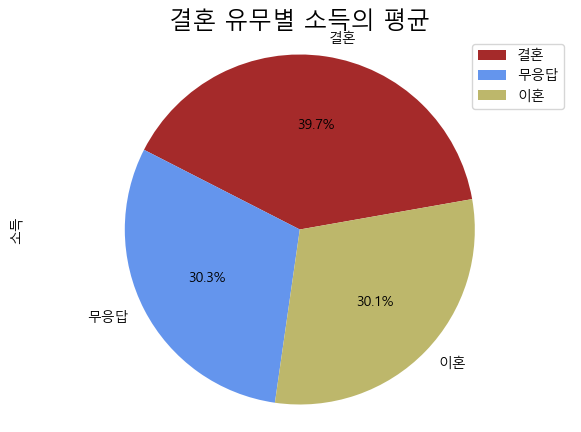

In [118]:
# plt.style.use('ggplot') 

# https://www.w3schools.com/colors/colors_names.asp
chartdata.plot(kind='pie',figsize=(7, 5),autopct='%1.1f%%',
         startangle=10, colors=['Brown', 'CornflowerBlue', 'DarkKhaki'])

plt.title('결혼 유무별 소득의 평균', size=17)
plt.axis('equal') 
plt.legend(labels=chartdata.index, loc='upper right')

<h6><font color="BlueViolet">소득과 나이의 산점도</font></h6>

Text(0.5, 1.0, '산점도 : 소득 vs 나이')

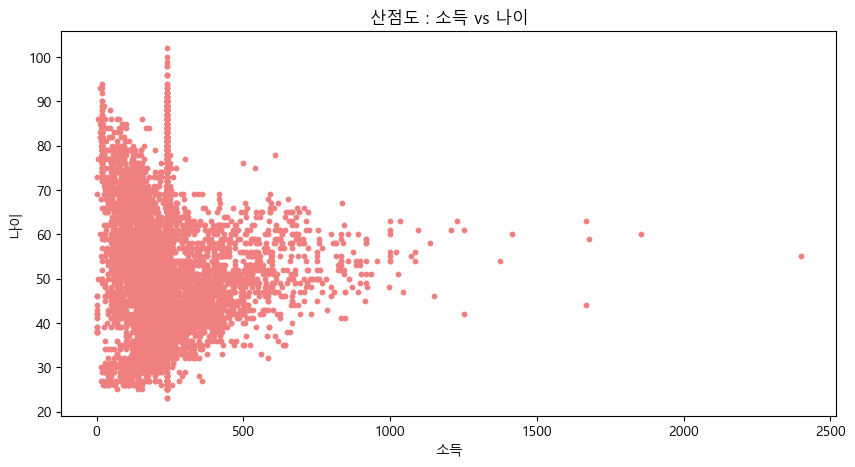

In [119]:
welfare.plot(kind='scatter', x='소득', y='나이',  c='LightCoral', \
             s=10, figsize=(10, 5))
plt.title('산점도 : 소득 vs 나이')

<h6><font color="BlueViolet">결혼 유무별 소득의 박스 플롯</font></h6>

In [120]:
marriage = [item for item in welfare['결혼 유무'].unique()]
print(marriage)
xData = []
for mar in marriage:
    xData.append(welfare[welfare['결혼 유무']==mar]['소득'])
# end for

# xData

['무응답', '이혼', '결혼']


Text(0.5, 1.0, '결혼 유무별 소득(박스 플롯)')

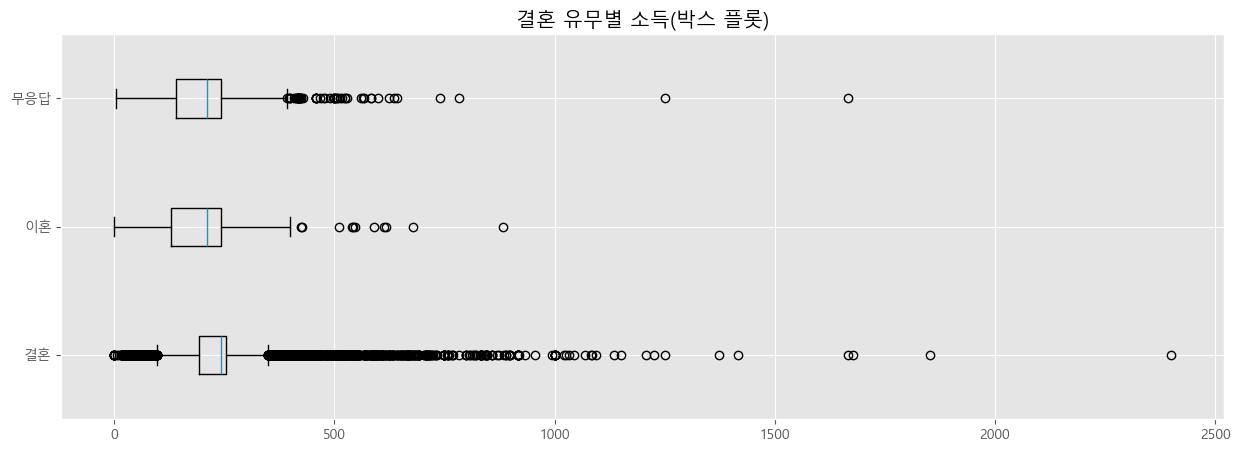

In [121]:
plt.style.use('ggplot') 
plt.figure(figsize=(15, 5))   

plt.boxplot(x=[welfare[welfare['결혼 유무']=='결혼']['소득'],
               welfare[welfare['결혼 유무']=='이혼']['소득'],
               welfare[welfare['결혼 유무']=='무응답']['소득']], 
         labels=['결혼', '이혼', '무응답'], vert=False)

plt.title('결혼 유무별 소득(박스 플롯)')

<h6><font color="BlueViolet">필요한 컬럼 추출하기</font></h6>

In [122]:
concern=['성별', '지역구', '나이', '소득']
welfare=welfare[concern]
welfare.head()

,성별,지역구,나이,소득
0,남성,서울,73,120.0
1,남성,서울,76,220.2
2,남성,서울,75,139.0
3,남성,서울,68,150.0
4,남성,서울,61,166.0


In [123]:
print('\'소득\' 컬럼에 누락된 데이터 확인 : ' + str(welfare.소득.hasnans))

'소득' 컬럼에 누락된 데이터 확인 : False


In [124]:
print('\'소득\' 컬럼의 형상 : ' + str(welfare.dropna(subset=['소득']).shape))

'소득' 컬럼의 형상 : (7529, 4)


In [125]:
welfare['소득'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
소득,7529.0,241.619016,144.679991,0.0,162.6,241.619016,241.619016,2400.0


In [126]:
welfare['소득'].sort_values(ascending=False).head(10).to_frame()

,소득
881,2400.00
7136,1853.30
7250,1678.70
5484,1666.70
2409,1666.66
4740,1416.70
5488,1374.00
5485,1250.00
7526,1250.00
4747,1226.70


In [127]:
welfare = welfare.loc[welfare['소득'] <= 1200 ]
print('소득 최대 값 : ' + str(welfare['소득'].max()))
print('소득 최소 값 : ' + str(welfare['소득'].min()))

소득 최대 값 : 1150.0
소득 최소 값 : 0.0


<h6><font color="BlueViolet">히스토그램 그리기</font></h6>

Text(0.5, 0, '소득')

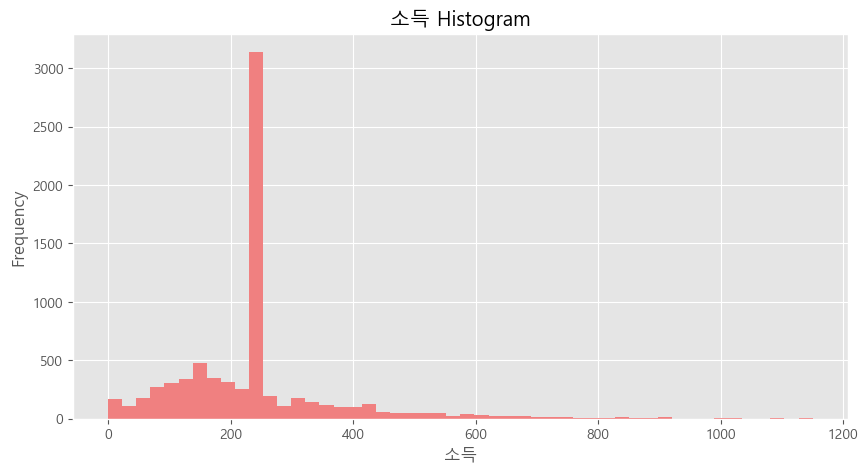

In [128]:
welfare['소득'].plot(kind='hist', bins=50, color='LightCoral', figsize=(10, 5))
plt.title('소득 Histogram')
plt.xlabel('소득')

<h6><font color="BlueViolet">데이터 이산화</font></h6>

In [129]:
import numpy as np
bins = [-np.inf, 200, 500, 700, 1000, np.inf]
cuts = pd.cut(welfare['소득'], bins=bins)
cuts.head()

0     (-inf, 200.0]
1    (200.0, 500.0]
2     (-inf, 200.0]
3     (-inf, 200.0]
4     (-inf, 200.0]
Name: 소득, dtype: category
Categories (5, interval[float64, right]): [(-inf, 200.0] < (200.0, 500.0] < (500.0, 700.0] < (700.0, 1000.0] < (1000.0, inf]]

In [130]:
cuts.value_counts().to_frame()

,count
소득,
"(200.0, 500.0]",4657
"(-inf, 200.0]",2473
"(500.0, 700.0]",280
"(700.0, 1000.0]",98
"(1000.0, inf]",10


In [131]:
# 이산화 소득별로 성별 비율 구하기
result = 100 * welfare.groupby(cuts, observed=False)['성별'].value_counts(normalize=True).round(4)
result.to_frame()

proportion
소득              성별            
(-inf, 200.0]   여성       68.62
                남성       31.38
(200.0, 500.0]  남성       62.47
                여성       37.53
(500.0, 700.0]  남성       83.57
                여성       16.43
(700.0, 1000.0] 남성       89.80
                여성       10.20
(1000.0, inf]   남성      100.00
                여성        0.00

In [132]:
# 이산화 소득별 25, 50, 75 퍼센트 지점의 값 확인
result = welfare.groupby(cuts, observed=False)['소득'].quantile(q=[.25, .5, .75]).round(4)
result.to_frame().head(6)

소득
소득                          
(-inf, 200.0]  0.25   81.200
               0.50  129.100
               0.75  160.800
(200.0, 500.0] 0.25  241.619
               0.50  241.619
               0.75  258.300

In [133]:
# 이산화 값을 한글로 변경하고 파생 컬럼으로 추가합니다.
mylabels = ['저소득', '중저소득', '중소득', '중고소득', '고소득']
cuts_label = pd.cut(welfare['소득'], bins=bins, labels=mylabels)

# 파생 컬럼으로 추가하기
welfare.loc[:, '범주형소득'] = cuts_label
welfare.head()

,성별,지역구,나이,소득,범주형소득
0,남성,서울,73,120.0,저소득
1,남성,서울,76,220.2,중저소득
2,남성,서울,75,139.0,저소득
3,남성,서울,68,150.0,저소득
4,남성,서울,61,166.0,저소득


<h6><font color="BlueViolet">지역별 소득 평균 그래프</font></h6>

In [134]:
chartdata = welfare.groupby('지역구')['소득'].mean()
chartdata.to_frame()

,소득
지역구,
강원/충북,221.955189
광주/전남/전북/제주도,234.901742
대구/경북,227.682571
대전/충남,254.458744
부산/경남/울산,251.044213
서울,246.926482
수도권,237.071017


Text(0.5, 0, '소득 평균')

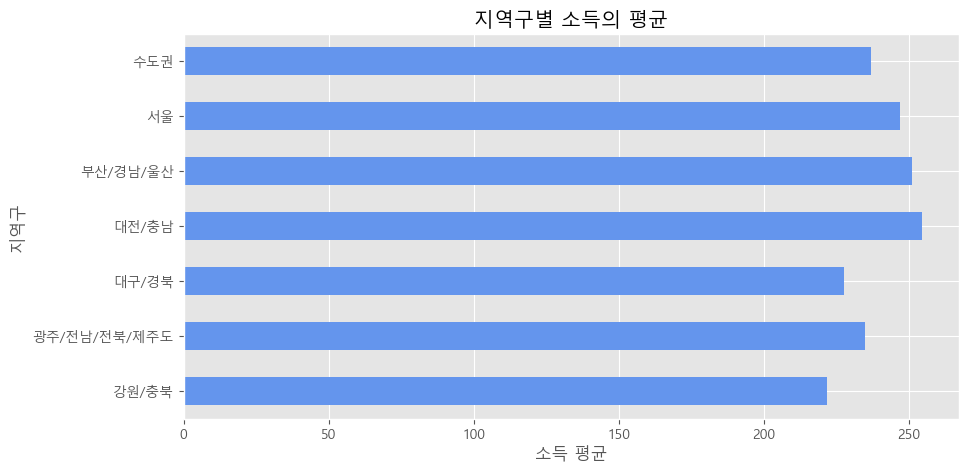

In [135]:
plt.style.use('ggplot') 
chartdata.plot(kind='barh', color='cornflowerblue', width=0.5, figsize=(10, 5))
plt.title('지역구별 소득의 평균')
plt.ylabel('지역구')
plt.xlabel('소득 평균')

<h6><font color="BlueViolet">성별/범주형 소득별 소득 평균</font></h6>

In [136]:
chartdata = welfare.groupby(['성별', '범주형소득'], observed=False)['소득'].mean().to_frame()
print(type(chartdata))
chartdata=chartdata.reset_index()
chartdata

<class 'pandas.core.frame.DataFrame'>


,성별,범주형소득,소득
0,남성,저소득,132.813144
1,남성,중저소득,277.966875
2,남성,중소득,586.030470
3,남성,중고소득,820.022273
4,남성,고소득,1074.030000
5,여성,저소득,114.459034
6,여성,중저소득,252.843971
7,여성,중소득,563.363261
8,여성,중고소득,833.383000
9,여성,고소득,NaN


In [137]:
chartdata = chartdata.pivot(index='성별', columns='범주형소득', values='소득')
chartdata

범주형소득,저소득,중저소득,중소득,중고소득,고소득
성별,,,,,
남성,132.813144,277.966875,586.030470,820.022273,1074.03
여성,114.459034,252.843971,563.363261,833.383000,NaN


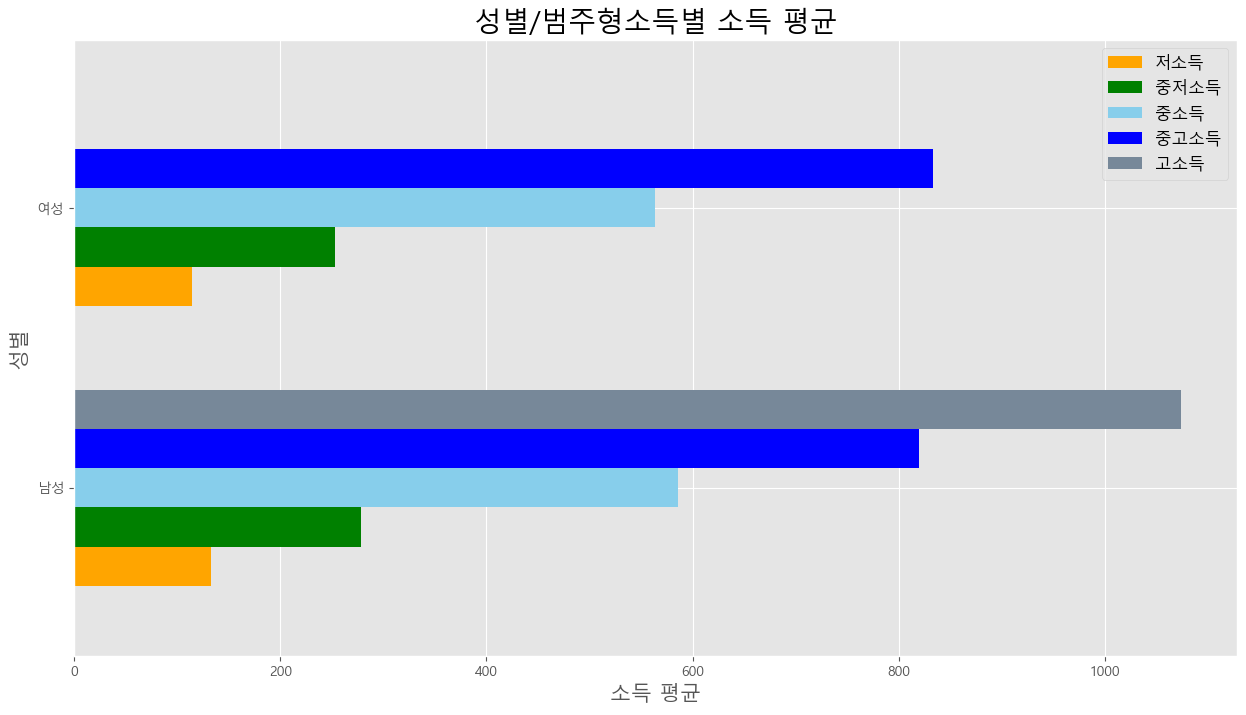

In [138]:
chartdata.plot(kind='barh', figsize=(15, 8), width=0.7,
          color=['orange', 'green', 'skyblue', 'blue', 'LightSlateGray'])

plt.title('성별/범주형소득별 소득 평균', size=20)
plt.ylabel('성별', size=15)
plt.xlabel('소득 평균', size=15)
plt.legend(loc='best', fontsize=12)

<h2><font color="red">특정 그룹 내 최대 값 찾기</font></h2>

<h4><font color="green">출장비 내역 파일 읽기</font></h4>

In [139]:
import pandas as pd

In [140]:
payment = pd.read_csv('./../data/payment07.csv', encoding='CP949')
payment

,사원명,출장지역,출장기간,부서,성별,교통비,식비
0,윤장혁,서울,7,영업부,남자,4000,2000
1,서문덕,서울,6,영업부,남자,3000,3000
2,이성진,부산,5,영업부,남자,3000,3000
3,강찬혁,부산,3,영업부,남자,1000,2000
4,신유석,서울,5,전산부,여자,2000,2000
5,유지혜,서울,5,전산부,여자,4000,1000
6,이유리,부산,8,전산부,여자,4000,1000
7,선진희,부산,6,전산부,여자,1000,4000


<h6><font color="BlueViolet">groupby와 rank 함수의 합성</font></h6>

In [141]:
payment['rank']=payment.groupby('부서')['교통비']. \
    rank(method='first', ascending=False)
payment

,사원명,출장지역,출장기간,부서,성별,교통비,식비,rank
0,윤장혁,서울,7,영업부,남자,4000,2000,1.0
1,서문덕,서울,6,영업부,남자,3000,3000,2.0
2,이성진,부산,5,영업부,남자,3000,3000,3.0
3,강찬혁,부산,3,영업부,남자,1000,2000,4.0
4,신유석,서울,5,전산부,여자,2000,2000,3.0
5,유지혜,서울,5,전산부,여자,4000,1000,1.0
6,이유리,부산,8,전산부,여자,4000,1000,2.0
7,선진희,부산,6,전산부,여자,1000,4000,4.0


<h6><font color="BlueViolet">랭킹 1순위 데이터 추출하기</font></h6>

In [142]:
result = payment[payment['rank'] == 1.0]
result

,사원명,출장지역,출장기간,부서,성별,교통비,식비,rank
0,윤장혁,서울,7,영업부,남자,4000,2000,1.0
5,유지혜,서울,5,전산부,여자,4000,1000,1.0


In [143]:
result = result.drop(columns=['rank'])
result

,사원명,출장지역,출장기간,부서,성별,교통비,식비
0,윤장혁,서울,7,영업부,남자,4000,2000
5,유지혜,서울,5,전산부,여자,4000,1000
